# Resolución de la Prueba 2: Laboratorio de Análisis Numérico Lineal
**Fecha:** 30 de enero de 2026  
**Materia:** Análisis Numérico 

## Problema 1: Aproximación Numérica de Integrales
Se desea aproximar la integral:
$$I = \int_{-1}^{1} |x|e^{x}dx$$

### Resolución Analítica
Debido a la presencia del valor absoluto $|x|$, debemos partir la integral en el punto crítico $x=0$:
$$I = \int_{-1}^{0} (-x)e^x dx + \int_{0}^{1} xe^x dx$$

Usando integración por partes $\int u dv = uv - \int v du$ con $u=x$ y $dv=e^xdx$:
1. $\int xe^x dx = xe^x - e^x + C$
2. Evaluación:
   * $\int_{0}^{1} xe^x dx = [xe^x - e^x]_0^1 = (e - e) - (0 - 1) = 1$
   * $\int_{-1}^{0} -xe^x dx = -[xe^x - e^x]_{-1}^0 = -[(-1) - (-e^{-1} - e^{-1})] = 1 - 2e^{-1}$

**Valor Exacto:** $I = 2 - 2e^{-1} \approx 1.26424111765$

### a) Sumas de Riemann (Superior e Inferior)
**Independencia de la elección:**
Para una función continua en un intervalo cerrado $[a, b]$, la función es **Riemann-integrable**. Esto implica que, a medida que el número de subintervalos tiende a infinito (o el diámetro de la partición tiende a cero), tanto la suma superior como la inferior convergen al mismo valor único: la integral definida. En este caso, $f(x) = |x|e^x$ es continua en $[-1, 1]$, por lo que la elección es independiente para la aproximación del límite.

In [4]:
import numpy as np

# Definición de la función
def f(x):
    return np.abs(x) * np.exp(x)

def aproximacion_riemann_detallada(n):
    # Subintervalo 1: [-1, 0]
    # f(x) = -x*e^x es decreciente en este intervalo. 
    # El mínimo (Suma Inferior) ocurre en el extremo derecho de cada subintervalo.
    x1 = np.linspace(-1, 0, n + 1)
    dx1 = x1[1] - x1[0]
    suma_inf_1 = np.sum(f(x1[1:]) * dx1) # Extremos derechos
    
    # Subintervalo 2: [0, 1]
    # f(x) = x*e^x es creciente en este intervalo.
    # El mínimo (Suma Inferior) ocurre en el extremo izquierdo de cada subintervalo.
    x2 = np.linspace(0, 1, n + 1)
    dx2 = x2[1] - x2[0]
    suma_inf_2 = np.sum(f(x2[:-1]) * dx2) # Extremos izquierdos
    
    total_aproximado = suma_inf_1 + suma_inf_2
    return total_aproximado

# Parámetros de la prueba
n_nodos = 1000
aprox = aproximacion_riemann_detallada(n_nodos)
valor_exacto = 2 - 2 * np.exp(-1)

print(f"--- Resultados Literal a) ---")
print(f"Número de subintervalos por tramo: {n_nodos}")
print(f"Aproximación por Sumas de Riemann: {aprox:.8f}")
print(f"Valor exacto analítico:           {valor_exacto:.8f}")
print(f"Error absoluto:                   {abs(valor_exacto - aprox):.8e}")

--- Resultados Literal a) ---
Número de subintervalos por tramo: 1000
Aproximación por Sumas de Riemann: 1.26269832
Valor exacto analítico:           1.26424112
Error absoluto:                   1.54279425e-03


### b) y c) Implementación y Gráficos Comparativos

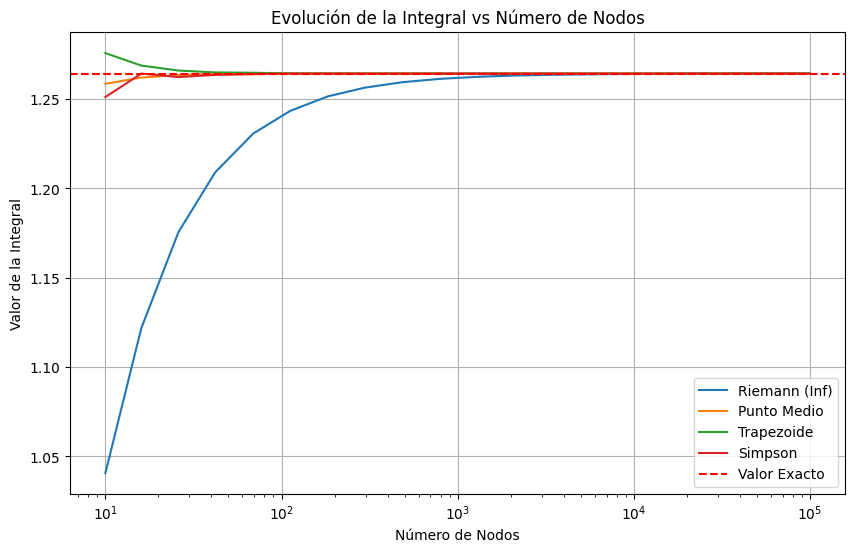

Valor exacto esperado: 1.2642411177


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf

# Definición de la función y valor exacto
f = lambda x: np.abs(x) * np.exp(x)
exact_val = 2 - 2 * np.exp(-1)

def sumas_riemman(f, a, b, n, mode='lower'):
    x = np.linspace(a, b, n+1)
    dx = (b - a) / n
    if mode == 'lower':
        return np.sum(f(x[:-1]) * dx)
    else:
        return np.sum(f(x[1:]) * dx)

def punto_medio(f, a, b, n):
    x = np.linspace(a, b, n+1)
    centers = (x[:-1] + x[1:]) / 2
    return np.sum(f(centers)) * (x[1] - x[0])

def trapecio(f, a, b, n):
    x = np.linspace(a, b, n+1)
    y = f(x)
    return ( (b-a) / (2*n) ) * (y[0] + 2*np.sum(y[1:-1]) + y[-1])

def simpson(f, a, b, n):
    if n % 2 != 0: n += 1 # Simpson requiere n par
    x = np.linspace(a, b, n+1)
    y = f(x)
    dx = (b - a) / n
    return (dx/3) * (y[0] + 4*np.sum(y[1:-1:2]) + 2*np.sum(y[2:-2:2]) + y[-1])

# --- c) Comparación de precisión ---
precis_goal = 1e-7
methods = {
    "Riemann (Inf)": lambda n: sumas_riemman(f, -1, 1, n, 'lower'),
    "Punto Medio": lambda n: punto_medio(f, -1, 1, n),
    "Trapezoide": lambda n: trapecio(f, -1, 1, n),
    "Simpson": lambda n: simpson(f, -1, 1, n)
}

resultados = {m: [] for m in methods}
n_values = np.logspace(1, 5, 20, dtype=int)

for n in n_values:
    for name, func in methods.items():
        resultados[name].append(func(n))

# Graficación
plt.figure(figsize=(10, 6))
for name, vals in resultados.items():
    plt.plot(n_values, vals, label=name)

plt.axhline(y=exact_val, color='r', linestyle='--', label='Valor Exacto')
plt.xscale('log')
plt.xlabel('Número de Nodos')
plt.ylabel('Valor de la Integral')
plt.title('Evolución de la Integral vs Número de Nodos')
plt.legend()
plt.grid(True)
plt.show()

print(f"Valor exacto esperado: {exact_val:.10f}")

## Problema 2: Solución de EDO mediante el Método de Heun
Se tiene el problema de valor inicial (PVI):
$$\begin{cases}y'(x) = xy + x^2 \\ y(0) = 1\end{cases}, \quad x \in (0, 1)$$

### Solución Exacta
La EDO es lineal de primer orden. El factor integrante es $\mu(x) = e^{\int -x dx} = e^{-x^2/2}$.
La solución general es:
$$y(x) = e^{x^2/2} \left( 1 + \int_0^x t^2 e^{-t^2/2} dt \right)$$
$$y(x) = e^{x^2/2} + \sqrt{\frac{\pi}{2}} e^{x^2/2} \text{erf}\left(\frac{x}{\sqrt{2}}\right) - x$$

### Método de Heun (Predictor-Corrector)
Dado $y_n$ en $x_n$:
1. **Predictor (Euler):** $\tilde{y}_{n+1} = y_n + h f(x_n, y_n)$
2. **Corrector (Trapezoide):** $y_{n+1} = y_n + \frac{h}{2} [f(x_n, y_n) + f(x_{n+1}, \tilde{y}_{n+1})]$

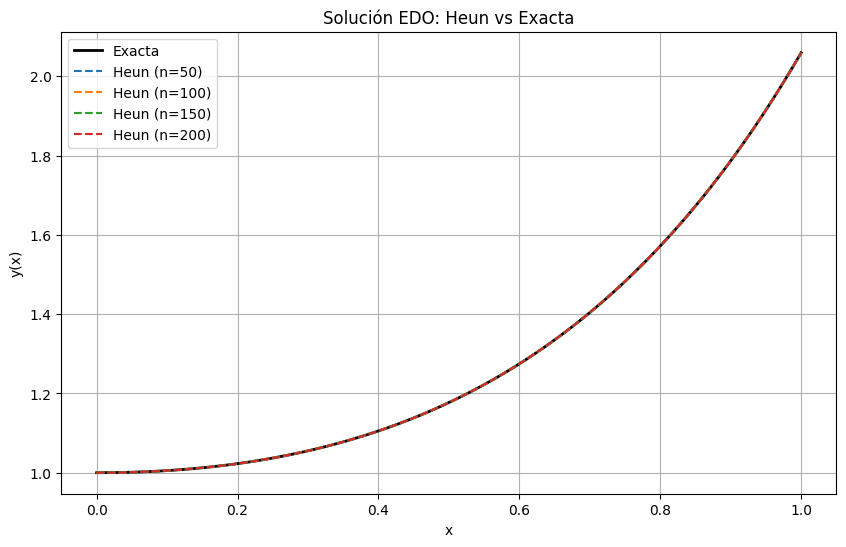

In [6]:
def heun(f_prime, x0, y0, xf, n):
    h = (xf - x0) / n
    x = np.linspace(x0, xf, n+1)
    y = np.zeros(n+1)
    y[0] = y0
    for i in range(n):
        f_n = f_prime(x[i], y[i])
        y_predict = y[i] + h * f_n
        y[i+1] = y[i] + (h/2) * (f_n + f_prime(x[i+1], y_predict))
    return x, y

def sol_exacta(x):
    return np.exp(x**2/2) * (1 + np.sqrt(np.pi/2) * erf(x/np.sqrt(2))) - x

# Parámetros
f_prima = lambda x, y: x*y + x**2
n_list = [50, 100, 150, 200]

plt.figure(figsize=(10, 6))
x_fine = np.linspace(0, 1, 500)
plt.plot(x_fine, sol_exacta(x_fine), 'k', lw=2, label='Exacta')

for n in n_list:
    x_h, y_h = heun(f_prima, 0, 1, 1, n)
    plt.plot(x_h, y_h, '--', label=f'Heun (n={n})')

plt.title('Solución EDO: Heun vs Exacta')
plt.xlabel('x')
plt.ylabel('y(x)')
plt.legend()
plt.grid(True)
plt.show()